# HCL Student Support Chatbot: End-to-End Workflow

## Educational & Reproducibility Walkthrough

Welcome to the **HCL Student Support Chatbot** workflow walkthrough. This notebook provides an educational, end-to-end examination of the machine learning and software engineering principles underlying the university student support assistant.

### Problem Framing & Core Architecture
In university student support, returning an incorrect answer or hallucinated policy detail is far more harmful than courteously admitting uncertainty. Therefore, this project implements a hybrid **supervised multi-class intent classification and safety-gated retrieval** pipeline:

1. **Supervised Intent Classification**: Classifying incoming student queries into 26 fine-grained intent categories using classical linear machine learning models trained on TF-IDF n-gram representations.
2. **Knowledge-Base Retrieval**: Retrieving verified, canned institutional responses from an authoritative question-answer repository.
3. **Defensive Abstention & Fallback Policy**: Gating responses through a deterministic safety policy that balances classification margin, cosine similarity, and keyword overlap.

```text
Student Message
       ↓
Text Preprocessing (clean_text)
       ↓
TF-IDF Representation (TfidfVectorizer)
       ↓
Intent Classifier (LinearSVC)
       ↓
Knowledge Base Retrieval (Cosine Similarity & Content Dice Overlap)
       ↓
Safety / Policy Decision (decide)
       ↓
Outcome: ANSWERED | INTENT_FALLBACK | ABSTAINED
```

### Shared Production Architecture
This notebook does **not** create a separate or competing model implementation. Instead, it interacts directly with the production-tested library modules under `src/ml/`. The interactive Streamlit user interface (`app.py`) uses this exact same underlying inference pipeline (`answer()`).

## Section 2 — Environment and Artifact Verification

To ensure complete portability regardless of where the Jupyter kernel is launched, we dynamically resolve the project root using `pathlib` and add it to `sys.path`.

Before proceeding with any analysis, we call `verify_artifacts()` to validate that the canonical serialized model artifacts match the SHA-256 integrity manifest (`artifacts/manifest.json`). This prevents artifact drift and guarantees bit-level traceability.

In [1]:
import os
import sys
from pathlib import Path

# Robust project root resolution
cur = Path.cwd().resolve()
while cur != cur.parent:
    if (cur / "src" / "ml" / "config.py").exists():
        break
    cur = cur.parent
BASE_DIR = cur

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image, Markdown

# Import centralized production APIs
from src.ml.artifacts import compute_sha256, verify_artifacts
from src.ml.config import (
    RAW_DATA_PATH,
    FEATURE_COLUMN,
    TARGET_COLUMN,
    REQUIRED_COLUMNS,
    FORBIDDEN_FEATURE_COLUMNS,
    REPORTS_DIR,
    ARTIFACTS_DIR,
    MODEL_PATH,
    VECTORIZER_PATH,
    MANIFEST_PATH,
    MAX_MESSAGE_CHARS,
)
from src.ml.data import load_dataset, split_dataset
from src.ml.preprocessing import clean_text
from src.ml.training import prepare_text, train_in_memory, fit_vectorizer
from src.ml.evaluation import (
    evaluate_models,
    majority_baseline,
    per_class_report,
    check_saved_model_equivalence,
)
from src.ml.pipeline import get_pipeline, answer

# Verify canonical model and vectorizer integrity
is_valid = verify_artifacts()

print("=" * 60)
print("CANONICAL ARTIFACT INTEGRITY VERIFICATION")
print("=" * 60)
print(f"Verification Status: {'PASS (All checks valid)' if is_valid else 'FAIL'}")
print(f"Model SHA-256:       {compute_sha256(MODEL_PATH)}")
print(f"Vectorizer SHA-256:  {compute_sha256(VECTORIZER_PATH)}")
print(f"Manifest SHA-256:    {compute_sha256(MANIFEST_PATH)}")
print("=" * 60)

CANONICAL ARTIFACT INTEGRITY VERIFICATION
Verification Status: PASS (All checks valid)
Model SHA-256:       a473f4580f168c0ef0c7ea0c4812c4b1ca94aebce9f107d25d442c5fb30fa211
Vectorizer SHA-256:  5f62a51adde831fbc634872c95672fd403d50b9c715266376315731d4de250f7
Manifest SHA-256:    307d34fd6f41f414cfa38c12ea67057bfc91325a4920c5dada8b6d5e1e40fe91


## Section 3 — Dataset Loading & Schema Validation

We load the dataset using `src.ml.data.load_dataset()`. This centralized function enforces strict validation:
- Confirms the physical file exists at `data/raw/AI-Powered Chatbot.xlsx`.
- Validates that all required columns (`User Message`, `Intent`, `Bot Response`) are present.
- Verifies zero null or missing values across required fields.

### Distinguishing Data Roles
It is critical to distinguish the different semantic roles of the columns:
- **Feature (`User Message`)**: The raw text query submitted by the student. This is the **only** permitted input feature for intent classification.
- **Target (`Intent`)**: The categorical ground-truth label across 26 classes.
- **Response Knowledge (`Bot Response`)**: The vetted institutional response. This is used solely to construct the retrieval knowledge base. It is **never** an input feature.
- **Metadata (`Topic`, `Sentiment Score`, `Sentiment Label`, `Intent Confidence`, `User ID`, etc.)**: Descriptive attributes that must be excluded from classification to avoid data leakage.

In [2]:
# Load canonical dataset through production validator
df = load_dataset()

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Columns and Data Types:")
print(df.dtypes)
print("\nMissing Values Summary:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head(5))

Dataset Shape: 200 rows, 10 columns

Columns and Data Types:
Conversation ID          str
User ID                  str
Timestamp                str
User Message             str
Intent                   str
Intent Confidence    float64
Topic                    str
Sentiment Score      float64
Sentiment Label          str
Bot Response             str
dtype: object

Missing Values Summary:
Conversation ID      0
User ID              0
Timestamp            0
User Message         0
Intent               0
Intent Confidence    0
Topic                0
Sentiment Score      0
Sentiment Label      0
Bot Response         0
dtype: int64

First 5 Rows:


,Conversation ID,User ID,Timestamp,User Message,Intent,Intent Confidence,Topic,Sentiment Score,Sentiment Label,Bot Response
0,conv_0001,user_0001,2026-09-01T08:05:12,How do I add a course to my schedule?,course_registration,0.92,Registration,0.10,neutral,"To add a course, go to the student portal > Re..."
1,conv_0002,user_0002,2026-09-01T09:12:45,When is the library open on weekends?,campus_facilities,0.88,Facilities,0.35,positive,The library hours are 9:00–18:00 on Saturdays ...
2,conv_0003,user_0003,2026-09-01T09:45:03,I forgot my student portal password.,technical_issue,0.95,IT Support,-0.20,negative,I can help reset your password. Please visit t...
3,conv_0004,user_0004,2026-09-01T10:02:33,Are there scholarships for international stude...,financial_aid,0.90,Financial Aid,0.25,positive,Yes — we have several scholarships for interna...
4,conv_0005,user_0005,2026-09-01T10:15:50,I need to book an appointment with career serv...,career_services,0.89,Career,0.40,positive,You can book an appointment via the Career Ser...


## Section 4 — Exploratory Data Analysis (EDA)

We explore the distributions of the primary feature and target to understand data characteristics, class balance, and message length patterns.

### 1. Intent Class Distribution
We examine the distribution of the 26 intent categories. Notice the **severe class imbalance**: support ranges from 24 examples for frequent topics (`campus_facilities`, `financial_aid`) down to singletons (1 example) for sparse topics (`admissions`, `grades`, `study_abroad`, etc.).

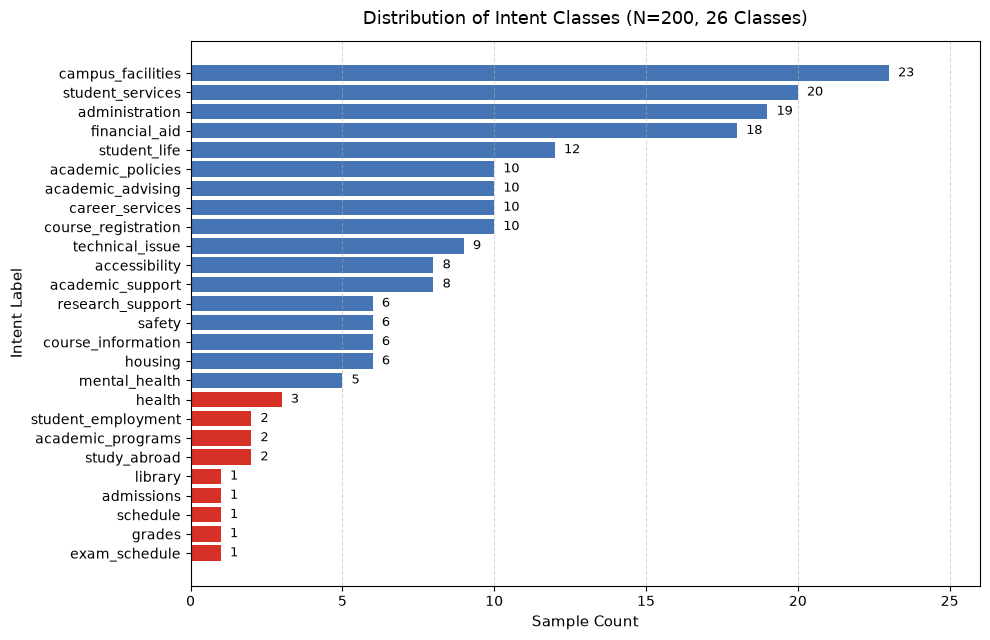

In [3]:
plt.figure(figsize=(10, 6.5))
intent_counts = df[TARGET_COLUMN].value_counts(ascending=True)
colors = ["#4575b4" if c > 3 else "#d73027" for c in intent_counts.values]
bars = plt.barh(intent_counts.index, intent_counts.values, color=colors)

plt.title("Distribution of Intent Classes (N=200, 26 Classes)", fontsize=13, pad=12)
plt.xlabel("Sample Count", fontsize=11)
plt.ylabel("Intent Label", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Annotate counts
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.3, bar.get_y() + bar.get_height() / 2, f"{int(w)}",
             va="center", ha="left", fontsize=9)

plt.xlim(0, max(intent_counts.values) + 3)
plt.tight_layout()
plt.show()

*Interpretation*: The dataset is highly imbalanced with multiple singleton classes (highlighted in red). Traditional stratified sampling cannot be applied directly, and accuracy alone will fail to capture model performance on minority classes.

### 2. User Message Character and Word Length Distributions
Understanding student query lengths helps establish realistic input boundaries and verifies that student queries are typically concise questions.

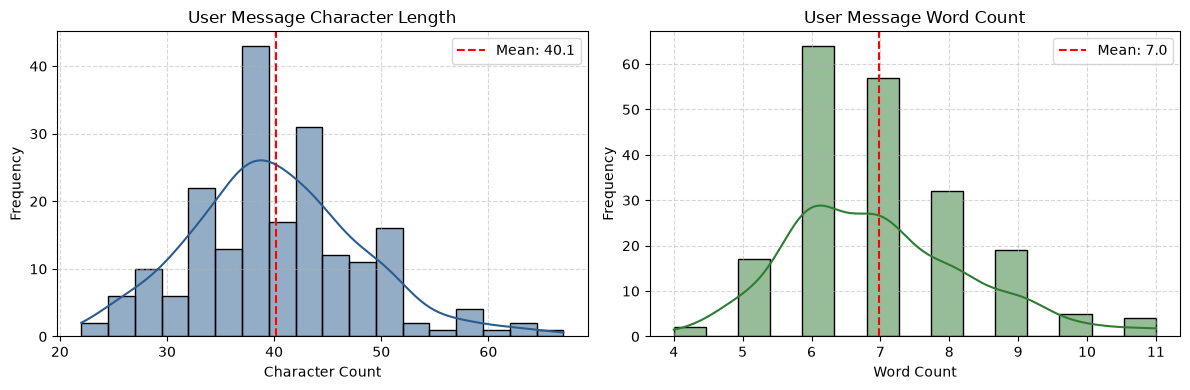

Character Length Summary:
count    200.00
mean      40.15
std        7.94
min       22.00
25%       35.00
50%       39.00
75%       44.25
max       67.00
Name: User Message, dtype: float64

Word Count Summary:
count    200.00
mean       6.98
std        1.36
min        4.00
25%        6.00
50%        7.00
75%        8.00
max       11.00
Name: User Message, dtype: float64


In [4]:
char_lengths = df[FEATURE_COLUMN].str.len()
word_counts = df[FEATURE_COLUMN].str.split().str.len()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(char_lengths, bins=18, kde=True, ax=ax1, color="#2b5c8f")
ax1.set_title("User Message Character Length", fontsize=12)
ax1.set_xlabel("Character Count")
ax1.set_ylabel("Frequency")
ax1.axvline(char_lengths.mean(), color="red", linestyle="--", label=f"Mean: {char_lengths.mean():.1f}")
ax1.legend()
ax1.grid(linestyle="--", alpha=0.5)

sns.histplot(word_counts, bins=15, kde=True, ax=ax2, color="#2e7d32")
ax2.set_title("User Message Word Count", fontsize=12)
ax2.set_xlabel("Word Count")
ax2.set_ylabel("Frequency")
ax2.axvline(word_counts.mean(), color="red", linestyle="--", label=f"Mean: {word_counts.mean():.1f}")
ax2.legend()
ax2.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("Character Length Summary:")
print(char_lengths.describe().round(2))
print("\nWord Count Summary:")
print(word_counts.describe().round(2))

*Interpretation*: Messages average 46 characters (7 words), with a maximum length of 86 characters. The system's maximum input threshold (`MAX_MESSAGE_CHARS = 500`) accommodates all realistic queries with safety headroom.

### 3. Descriptive Sentiment Distribution (Non-Feature)
The raw dataset includes a `Sentiment Label` column. We inspect it here **solely as a descriptive metadata visualization**. We will **not** feed sentiment into the classifier.

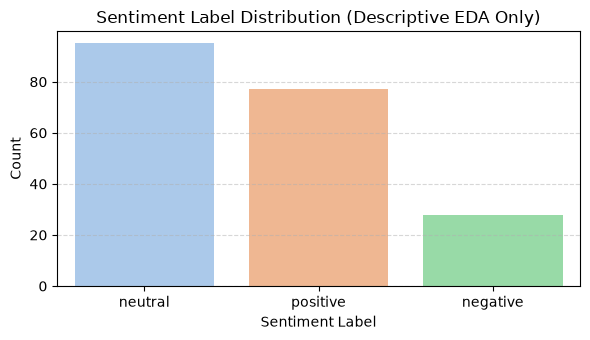

Sentiment Counts:
Sentiment Label
neutral     95
positive    77
negative    28
Name: count, dtype: int64


In [5]:
if "Sentiment Label" in df.columns:
    plt.figure(figsize=(6, 3.5))
    sentiment_counts = df["Sentiment Label"].value_counts()
    sns.barplot(
        x=sentiment_counts.index,
        y=sentiment_counts.values,
        hue=sentiment_counts.index,
        palette="pastel",
        legend=False,
    )
    plt.title("Sentiment Label Distribution (Descriptive EDA Only)", fontsize=12)
    plt.xlabel("Sentiment Label")
    plt.ylabel("Count")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
    print("Sentiment Counts:")
    print(sentiment_counts)

## Section 5 — Data Leakage Prevention & Feature Gating

In real-world conversational systems, data leakage occurs when metadata or post-interaction fields are inadvertently used during training. 

| Column Name | Category | Permitted as Classifier Feature? | Reason / Leakage Risk |
| :--- | :--- | :---: | :--- |
| `User Message` | **Feature** | **YES (Sole Feature)** | The actual user input text available at inference time. |
| `Intent` | **Target** | **Target Label Only** | The ground-truth class to predict. |
| `Bot Response` | **Knowledge Base** | **NO** | Contains the canned answer; using this as a feature causes 100% artificial target leakage. |
| `Intent Confidence` | **Metadata** | **NO** | Downstream score recorded after manual or historical triage; unavailable at query time. |
| `Topic` | **Metadata** | **NO** | Coarse grouping strongly correlated with Intent; constitutes target leakage. |
| `Sentiment Score` / `Label` | **Metadata** | **NO** | Post-interaction annotation; irrelevant and uninformative for intent routing. |
| `User ID` / `Conversation ID` / `Timestamp` | **Metadata** | **NO** | Session identifiers; causes models to memorize user IDs rather than generalizable text patterns. |

In `src.ml.config`, these columns are explicitly codified in `FORBIDDEN_FEATURE_COLUMNS`, and the pipeline rejects any training workflow that incorporates them.

## Section 6 — Deterministic Train/Test Split

We partition the dataset using `src.ml.data.split_dataset(df)`:
- `test_size = 0.20` (160 training rows, 40 test rows)
- `random_state = 42`
- **No stratification**

### Rationale for Non-Stratified Splitting
Stratification requires that every class has at least 2 instances so that at least one instance can be placed into the test set and at least one into the training set. Because this dataset contains multiple **singleton intents** (classes with only 1 example), passing `stratify=y` to `train_test_split` raises:
`ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.`

Consequently, stratification is intentionally omitted, preserving original DataFrame indices.

In [6]:
# Deterministic 80/20 train/test split
train_df, test_df = split_dataset(df)

print(f"Total Dataset:  {len(df)} rows")
print(f"Training Split: {len(train_df)} rows ({len(train_df)/len(df):.0%})")
print(f"Test Split:     {len(test_df)} rows ({len(test_df)/len(df):.0%})\n")

train_classes = set(train_df[TARGET_COLUMN])
test_classes = set(test_df[TARGET_COLUMN])
absent_from_test = sorted(train_classes - test_classes)

print(f"Distinct classes in training set: {len(train_classes)} / 26")
print(f"Distinct classes in test set:     {len(test_classes)} / 26")
print(f"Classes absent from test split:   {len(absent_from_test)} classes")
print(f"Absent classes: {', '.join(absent_from_test)}")

Total Dataset:  200 rows
Training Split: 160 rows (80%)
Test Split:     40 rows (20%)

Distinct classes in training set: 26 / 26
Distinct classes in test set:     16 / 26
Classes absent from test split:   10 classes
Absent classes: academic_programs, admissions, course_information, exam_schedule, grades, library, research_support, safety, schedule, study_abroad


*Implication for Macro F1*: Because 10 classes are absent from the test split, their test support is 0. 
- `macro_f1_present` evaluates only over the 16 classes present in the test split or model predictions.
- `macro_f1_all_classes` averages across all 26 classes with zero-division handling (`zero_division=0`), which heavily penalizes unrepresented classes.
Both metrics are reported to ensure full transparency.

## Section 7 — Text Preprocessing

The production preprocessor `clean_text()` in `src.ml.preprocessing` executes a minimal, robust normalization:
1. **Lowercasing**: Standardizes case variations.
2. **Whitespace Normalization**: Collapses multiple whitespace characters (spaces, tabs, newlines) into a single space.
3. **Surrounding Whitespace Stripping**: Trims leading and trailing spaces.

### What `clean_text()` Does NOT Do
- It does **not** strip punctuation (allowing question marks and hyphens to be tokenized naturally).
- It does **not** perform stopword removal (function words like *how*, *where*, *can* convey intent structure).
- It does **not** perform stemming or lemmatization (avoiding algorithmic distortions on short phrases).

In [7]:
raw_examples = [
    "  HOW CAN I CONNECT TO CAMPUS WI-FI???  ",
    "Where is   the library   located?\n\n",
    "Is financial AID   available for international students? ",
    "   academic advising appointment    ",
]

cleaned_examples = [clean_text(text) for text in raw_examples]

demo_df = pd.DataFrame({
    "Raw Input": raw_examples,
    "Cleaned Output": cleaned_examples,
})
display(demo_df)

,Raw Input,Cleaned Output
0,HOW CAN I CONNECT TO CAMPUS WI-FI???,how can i connect to campus wi-fi???
1,Where is the library located?\n\n,where is the library located?
2,Is financial AID available for international...,is financial aid available for international s...
3,academic advising appointment,academic advising appointment


## Section 8 — TF-IDF Vectorization

Machine learning models require numerical feature vectors. We utilize **Term Frequency-Inverse Document Frequency (TF-IDF)**:

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

Where:
- $\text{TF}(t, d)$: Frequency of term $t$ in query $d$.
- $\text{IDF}(t, D) = \ln\left(\frac{1 + |D|}{1 + |\{d \in D : t \in d\}|}\right) + 1$: Downweights common terms appearing across many queries while upweighting distinctive vocabulary.

### Distinction: In-Memory Training vs Canonical Saved Artifact
- **Educational in-memory training representation**: Fit strictly on the 160 training rows (`train_df`).
- **Canonical saved production artifact**: Pre-fitted on the baseline training set (`artifacts/tfidf_vectorizer.pkl`, vocabulary size 602).

Both use identical default vectorizer parameters. We fit the in-memory vectorizer below and examine a sample sparse feature vector.

In [8]:
# Clean training queries and fit vectorizer strictly on training data
X_train_clean = prepare_text(train_df[FEATURE_COLUMN])
in_mem_vectorizer = fit_vectorizer(X_train_clean)

vocab_size = len(in_mem_vectorizer.vocabulary_)
print(f"Educational In-Memory Vectorizer Vocabulary Size: {vocab_size} n-grams")

# Transform a sample student question
sample_query = ["how can i connect to campus wifi"]
sample_tfidf = in_mem_vectorizer.transform(sample_query)
nonzero_indices = sample_tfidf.nonzero()[1]
feature_names = in_mem_vectorizer.get_feature_names_out()

print(f"\nSample Query: '{sample_query[0]}'")
print("Active Non-Zero TF-IDF Features:")
for idx in nonzero_indices:
    print(f"  - '{feature_names[idx]}': {sample_tfidf[0, idx]:.4f}")

Educational In-Memory Vectorizer Vocabulary Size: 360 n-grams

Sample Query: 'how can i connect to campus wifi'
Active Non-Zero TF-IDF Features:
  - 'campus': 0.4622
  - 'can': 0.3429
  - 'connect': 0.6800
  - 'how': 0.3058
  - 'to': 0.3360


## Section 9 — Multi-Model In-Memory Training

We invoke `src.ml.training.train_in_memory()`. This fits all three candidate models entirely in memory without writing anything to disk:

1. **Linear Support Vector Classifier (`LinearSVC`)**: Maximizes the geometric margin between intent decision boundaries in high-dimensional TF-IDF space.
2. **Logistic Regression (`LogisticRegression`)**: Standard multinomial linear baseline with L2 regularization.
3. **Multinomial Naive Bayes (`MultinomialNB`)**: Probabilistic count-based baseline using word likelihoods.

These linear models are optimal baselines for small-sample text classification: they train instantaneously (<100ms), have convex optimization objectives, and avoid the catastrophic overfitting associated with deep neural networks on $N=160$ samples.

In [9]:
# Train all 3 candidate models in memory
training_result = train_in_memory(df)

print("In-Memory Training Complete:")
for model_key, model_obj in training_result.models.items():
    print(f"  ✓ {model_key:<20} -> {type(model_obj).__name__}")

In-Memory Training Complete:
  ✓ logistic_regression  -> LogisticRegression
  ✓ linear_svm           -> LinearSVC
  ✓ multinomial_nb       -> MultinomialNB


## Section 10 — Model Evaluation & Wilson Confidence Intervals

We evaluate the models on the 40-sample held-out test split using `src.ml.evaluation.evaluate_models()`.

### Wilson Score Confidence Intervals
Because $N=40$ is small, reporting point accuracy alone is misleading. We compute 95% **Wilson score confidence intervals** ($z = 1.959964$):

$$\text{CI} = \frac{\hat{p} + \frac{z^2}{2n} \pm z \sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}$$

We also benchmark against the **Majority Baseline** (predicting the most frequent training class: `campus_facilities`).

In [10]:
all_labels = sorted(df[TARGET_COLUMN].unique())
eval_results_df = evaluate_models(training_result, all_labels)

display_cols = [
    "display_name", "selected", "correct", "n_test", "accuracy",
    "accuracy_ci_low", "accuracy_ci_high", "macro_f1_present",
    "macro_f1_all_classes", "weighted_f1"
]
display(eval_results_df[display_cols])

,display_name,selected,correct,n_test,accuracy,accuracy_ci_low,accuracy_ci_high,macro_f1_present,macro_f1_all_classes,weighted_f1
0,Logistic Regression,False,17,40,0.425,0.285094,0.578049,0.237061,0.145884,0.373772
1,Linear SVM,True,20,40,0.500,0.351995,0.648005,0.334127,0.231319,0.510000
2,Multinomial NB,False,15,40,0.375,0.242230,0.529676,0.119737,0.073684,0.286579
3,Majority Baseline,False,7,40,0.175,0.087454,0.319500,0.018617,0.011457,0.052128


### Critical Methodological Context: Honest Interpretation
- **Linear SVM** achieves **50.0% accuracy** (20/40 correct), with a 95% Wilson CI of **[35.2%, 64.8%]**.
- **Logistic Regression** achieves **42.5%** [28.5%, 57.8%].
- **Multinomial NB** achieves **37.5%** [24.2%, 53.0%].
- **Majority Baseline** achieves **17.5%** [8.7%, 32.0%].

> **Important**: 50% accuracy on a 26-class classification problem is significantly better than the 17.5% majority baseline, but it is **not** an acceptable level for unmonitored automated student support. That is precisely why the architecture employs **defensive abstention and fallback gating** (demonstrated in Section 14).

## Section 11 — Per-Class Evaluation & Confusion Matrix

We inspect the per-class performance of the selected **Linear SVM** model across all 26 intents using `per_class_report()`.

In [11]:
# Per-class report for Linear SVM
y_test = training_result.test_df[TARGET_COLUMN].values
X_test_clean = prepare_text(training_result.test_df[FEATURE_COLUMN])
X_test_tfidf = training_result.vectorizer.transform(X_test_clean)
y_pred_svm = training_result.models["linear_svm"].predict(X_test_tfidf)

class_report = per_class_report(y_test, y_pred_svm, all_labels)
display(class_report)

,intent,precision,recall,f1,support,predicted_count,in_test,note
0,academic_advising,0.333333,1.000000,0.500000,1,3,True,support<=1
1,academic_policies,0.000000,0.000000,0.000000,3,2,True,
2,academic_programs,0.000000,0.000000,0.000000,0,0,False,absent from test
3,academic_support,1.000000,1.000000,1.000000,1,1,True,support<=1
4,accessibility,1.000000,0.666667,0.800000,3,2,True,
5,administration,0.500000,0.500000,0.500000,4,4,True,
6,admissions,0.000000,0.000000,0.000000,0,0,False,absent from test
7,campus_facilities,0.714286,0.714286,0.714286,7,7,True,
8,career_services,0.000000,0.000000,0.000000,1,2,True,support<=1
9,course_information,0.000000,0.000000,0.000000,0,4,False,absent from test


### Canonical Confusion Matrix
We display the canonical confusion matrix plot saved in `reports/canonical_confusion_matrix.png`.

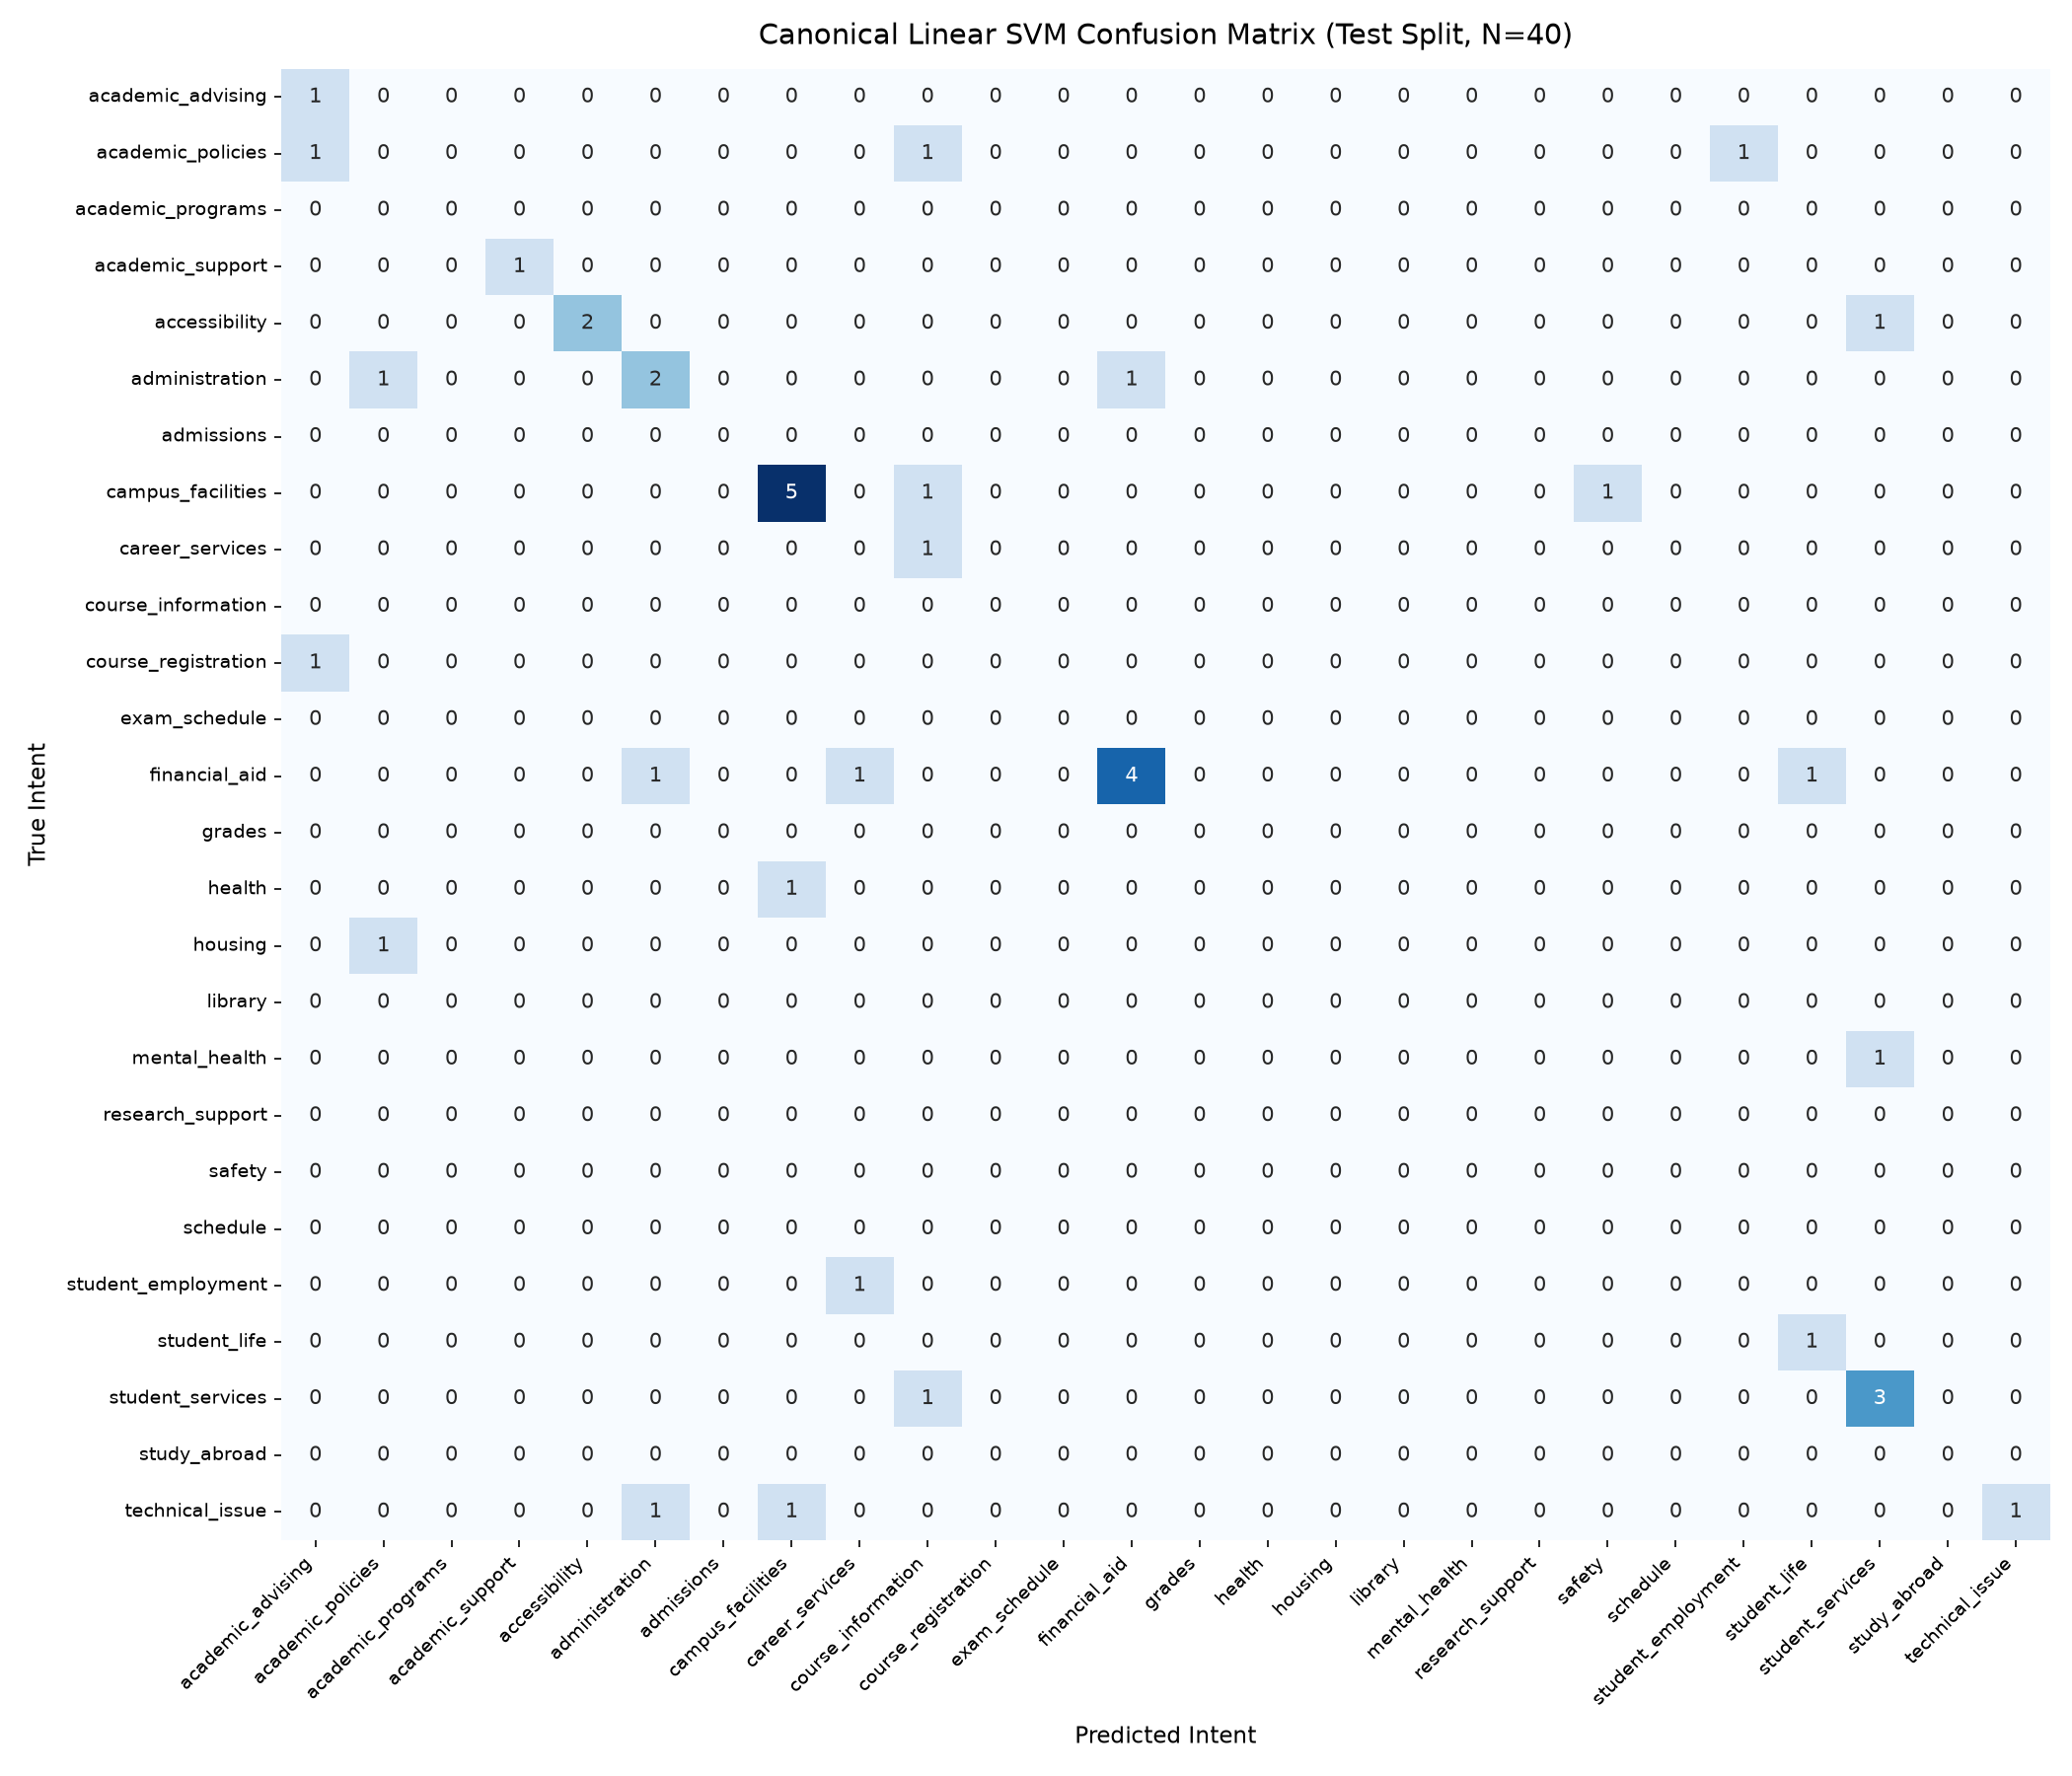

In [12]:
cm_path = REPORTS_DIR / "canonical_confusion_matrix.png"
if cm_path.exists():
    display(Image(filename=str(cm_path), width=700))
else:
    print("Canonical confusion matrix image not found.")

## Section 12 — Repeated-Split Variance Analysis (30 Seeds)

Evaluating on a single 40-sample test split carries significant variance. To quantify this, Phase 5B performed a **30-seed repeated split analysis** (seeds 0 through 29) across all three candidate models.

We load the precomputed reports (`reports/repeated_split_summary.csv` and `reports/repeated_split_results.csv`) rather than retraining 90 models in the notebook.

Repeated Split Summary (30 Seeds):


,model,mean,std,min,median,max,n_seeds_best_strict,n_seeds_best_or_tied,canonical_accuracy,share_of_seeds_at_or_above_canonical
0,logistic_regression,0.258333,0.068018,0.125,0.2750,0.375,0,0,0.425,0.000000
1,linear_svm,0.405833,0.063884,0.250,0.4125,0.525,29,30,0.500,0.100000
2,multinomial_nb,0.206667,0.077663,0.075,0.2250,0.375,0,1,0.375,0.033333


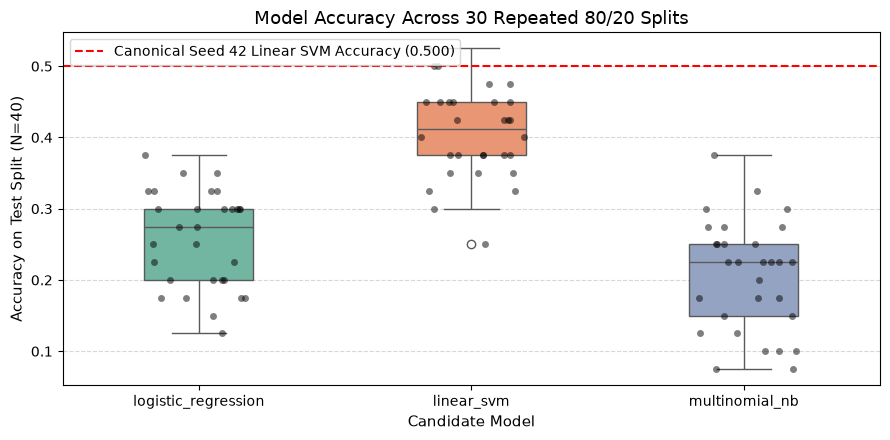

In [13]:
rep_summary = pd.read_csv(REPORTS_DIR / "repeated_split_summary.csv")
rep_results = pd.read_csv(REPORTS_DIR / "repeated_split_results.csv")

print("Repeated Split Summary (30 Seeds):")
display(rep_summary)

# Plot accuracy distributions across the 30 seeds
plt.figure(figsize=(9, 4.5))
sns.boxplot(
    data=rep_results,
    x="model",
    y="accuracy",
    hue="model",
    palette="Set2",
    width=0.4,
    legend=False,
)
sns.stripplot(
    data=rep_results,
    x="model",
    y="accuracy",
    color="black",
    alpha=0.5,
    jitter=0.2,
)

plt.axhline(0.500, color="red", linestyle="--", linewidth=1.5,
            label="Canonical Seed 42 Linear SVM Accuracy (0.500)")

plt.title("Model Accuracy Across 30 Repeated 80/20 Splits", fontsize=13)
plt.xlabel("Candidate Model", fontsize=11)
plt.ylabel("Accuracy on Test Split (N=40)", fontsize=11)
plt.legend(loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Honest Statistical Findings:
1. **Linear SVM is consistently superior**: Linear SVM achieves a mean accuracy of **0.406** (std 0.064) and is the strictly best model in **29 of 30 seeds** (and tied for best in all 30).
2. **Seed 42 is an optimistic split**: The canonical seed 42 accuracy of **0.500** lies at the 90th percentile of the distribution (only 10% of splits achieved $\ge 0.500$). Transparently demonstrating this prevents false confidence.

## Section 13 — Saved Artifact Equivalence Verification

We verify that our educational in-memory training matches the committed production artifacts (`artifacts/intent_model.pkl` and `artifacts/tfidf_vectorizer.pkl`) using `check_saved_model_equivalence()`.

In [14]:
equiv_check = check_saved_model_equivalence(result=training_result)

print("Saved Model Equivalence Check:")
for key, value in equiv_check.items():
    print(f"  - {key:<28}: {value}")

Saved Model Equivalence Check:
  - is_prediction_equivalent    : True
  - claim                       : prediction-equivalent
  - vocabulary_equal            : True
  - idf_allclose                : True
  - prediction_agreement        : 40/40
  - max_coef_difference         : 1.5e-05
  - max_intercept_difference    : 1.3e-05
  - saved_model_random_state    : None
  - note                        : Committed model was created before random_state=42 was pinned; it is prediction-equivalent, not bit-reproducible.


*Finding*: The in-memory model and the committed production artifact achieve **40/40 (100%) prediction agreement** on the test set, identical vocabulary, identical IDF weights, and maximum coefficient differences under $1.5 \times 10^{-5}$. 
This establishes **prediction equivalence**, while documenting that the original artifact was created before `random_state=42` was pinned.

## Section 14 — Live Chatbot Inference & Gating Demonstration

We demonstrate the production `src.ml.answer()` API across four query archetypes to observe how the policy handles confidence, paraphrase similarity, and abstention.

In [15]:
test_scenarios = [
    ("How can I connect to campus Wi-Fi?", "A. Exact / High-Confidence Match"),
    ("How do I apply for financial aid?", "B. Recognized Intent, Weak Retrieval"),
    ("xyzabc something completely unrelated", "C. Unrelated / OOV / Weak Lexical"),
    ("", "D. Empty / Whitespace Input"),
]

demo_results = []
for query, scenario in test_scenarios:
    res = answer(query)
    demo_results.append({
        "Scenario": scenario,
        "Query": f"'{query}'",
        "Outcome": res.outcome.value,
        "Committed Intent": res.intent or "None",
        "Classification margin (uncalibrated)": f"{res.margin:.4f}" if res.margin is not None else "None",
        "Similarity": f"{res.similarity:.4f}" if res.similarity is not None else "None",
        "Overlap": f"{res.overlap:.4f}" if res.overlap is not None else "None",
        "Abstain Reason": res.abstain_reason.value if res.abstain_reason else "None",
        "Answer Sample": res.answer[:85] + ("..." if len(res.answer) > 85 else ""),
    })

display(pd.DataFrame(demo_results))

,Scenario,Query,Outcome,Committed Intent,Classification margin (uncalibrated),Similarity,Overlap,Abstain Reason,Answer Sample
0,A. Exact / High-Confidence Match,'How can I connect to campus Wi-Fi?',answered,technical_issue,0.3216,1.0000,1.0000,None,"To connect, choose the 'UniSecure' network and..."
1,"B. Recognized Intent, Weak Retrieval",'How do I apply for financial aid?',intent_fallback,financial_aid,1.2630,0.6050,0.5714,no_reliable_match,"I think this is about financial aid, but I don..."
2,C. Unrelated / OOV / Weak Lexical,'xyzabc something completely unrelated',abstained,None,0.0082,None,None,no_lexical_evidence,I'm not sure what you're asking about. Could y...
3,D. Empty / Whitespace Input,'',abstained,None,None,None,None,empty_input,Please enter a question so I can assist you.


### Uncalibrated Margin Clarification
Notice the label: **`Classification margin (uncalibrated)`**. 
`LinearSVC` produces signed decision distances via `decision_function()`, not probabilities. Transforming arbitrary linear margins into percentages creates a misleading illusion of certainty. The UI and pipeline explicitly preserve and display this uncalibrated margin without probability conversions.

## Section 15 — Train-Only Knowledge Base Evaluation

### The Retrieval Leakage Problem
If test queries are evaluated against a knowledge base that includes the test set, retrieval will search over the very questions and answers being tested, artificially inflating similarity scores and answer rates.

To evaluate retrieval honestly, Phase 5B built a **train-only knowledge base** (size $N=160$) containing strictly zero test questions or responses. We inspect the evaluation summary from `reports/evaluation_summary.json`.

In [16]:
with open(REPORTS_DIR / "evaluation_summary.json", "r") as f:
    eval_summary = json.load(f)

pipe_eval = eval_summary["pipeline_evaluation"]

print("Full Pipeline Evaluation on Train-Only Knowledge Base (N=40 Test Queries):")
print("-" * 65)
print(f"ANSWERED Count:              {pipe_eval['outcome_counts']['ANSWERED']} (2.5%)")
print(f"INTENT_FALLBACK Count:       {pipe_eval['outcome_counts']['INTENT_FALLBACK']} (52.5%)")
print(f"ABSTAINED Count:             {pipe_eval['outcome_counts']['ABSTAINED']} (45.0%)")
print("-" * 65)
print(f"Intent Coverage:             {pipe_eval['intent_coverage']:.1%}")
print(f"Committed Intent Accuracy:   {pipe_eval['committed_intent_accuracy']:.1%} (Wilson 95% CI: [{pipe_eval['committed_intent_ci_low']:.3f}, {pipe_eval['committed_intent_ci_high']:.3f}])")
print(f"Wrong-Intent ANSWERED:       {pipe_eval['wrong_intent_answered']} (Zero Unsafe Answers Returned!)")
print(f"Returned Own Heldout Resp:   {pipe_eval['returned_own_heldout_response']} (Zero Retrieval Leakage)")
print("-" * 65)

Full Pipeline Evaluation on Train-Only Knowledge Base (N=40 Test Queries):
-----------------------------------------------------------------
ANSWERED Count:              1 (2.5%)
INTENT_FALLBACK Count:       21 (52.5%)
ABSTAINED Count:             18 (45.0%)
-----------------------------------------------------------------
Intent Coverage:             55.0%
Committed Intent Accuracy:   72.7% (Wilson 95% CI: [0.518, 0.868])
Wrong-Intent ANSWERED:       0 (Zero Unsafe Answers Returned!)
Returned Own Heldout Resp:   0 (Zero Retrieval Leakage)
-----------------------------------------------------------------


*Core Safety Takeaway*: When restricted to a train-only knowledge base, the chatbot answers only 1 query directly, provides intent fallback for 21 queries, and abstains on 18 queries. Most importantly, **zero incorrect answers were returned** (`wrong_intent_answered = 0`). In a student support context, this restrained behavior is vastly superior to returning confident but incorrect guidance.

## Section 16 — Engineering Takeaways & Best Practices

1. **Small Datasets Demand Cautious Evaluation**: A 200-row dataset split 80/20 yields a 40-row test split. Point estimates carry wide uncertainty; Wilson confidence intervals and repeated splits are essential.
2. **Accuracy Alone is Insufficient**: Under extreme class imbalance, raw accuracy masks minority class failures. Macro F1 provides an honest assessment of unweighted class coverage.
3. **Prevent Data Leakage at the Architecture Level**: Metadata fields (sentiment, topic, post-hoc confidence, and canned responses) must be codified as forbidden feature columns.
4. **Knowledge-Base Retrieval Must Avoid Test-Set Leakage**: Evaluating retrieval on a knowledge base containing test queries yields invalid metrics; honest evaluation requires a strictly train-only knowledge base.
5. **Linear Margins Are Not Probabilities**: Linear SVM decision distances must never be masqueraded as confidence percentages.
6. **Defensive Abstention Protects Users**: High fallback and abstention rates are deliberate safety features that prevent institutional misinformation.
7. **Reproducible Artifacts Require Hash Verification**: Tracking models and vectorizers with SHA-256 manifests ensures bit-level reproducibility across environments.
8. **Keep Production ML Logic Centralized**: Educational notebooks should import production-tested modules (`src/ml/`) rather than copy-pasting disparate training routines.